# Prediction Benchmark and Process Understanding for `SLURRY_FREE_ACID`

This notebook is the controlled modeling stage of the TSP fertilizer forecasting project. It preserves the executed preparation methodology from Notebook 02 and compares four direct horizons and four feature-set hypotheses.

The primary question is not merely which model has the lowest error. It is whether any model improves on persistence at a horizon that provides useful reaction time, remains understandable, and behaves acceptably during process transitions.

No feature is interpreted causally. No operating recommendation is authorized unless the variable registry explicitly marks the variable as confirmed controllable.


## 1. Configuration and reproducibility


### 1.1 Imports


In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import importlib.util
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

warnings.filterwarnings("ignore")


### 1.2 Central experiment configuration


In [2]:
RANDOM_STATE = 42
HORIZONS = [1, 5, 10, 15]
FEATURE_SETS = ["A_raw", "B_temporal", "C_process", "D_full"]
ML_MODELS = ["ridge", "extra_trees", "hist_gradient_boosting"]
BASELINES = ["training_mean", "persistence"]

PREPARATION_NOTEBOOK = Path("02_feature_engineering_data_preparation.ipynb")
ARTIFACT_INPUT_DIR = Path("../reports/feature_preparation_artifacts")
ARTIFACT_OUTPUT_DIR = Path("../reports/prediction_benchmark_artifacts")
FIGURE_DIR = ARTIFACT_OUTPUT_DIR / "figures"
MODEL_DIR = ARTIFACT_OUTPUT_DIR / "models"

TUNING_BUDGET_PER_MODEL = 2
EXTRA_TREES_ESTIMATORS = 30
PERMUTATION_SAMPLE_ROWS = 2000
PERMUTATION_REPEATS = 2
PREDICTION_PLOT_ROWS = 1500

ARTIFACT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
plt.style.use("seaborn-v0_8-whitegrid")


### 1.3 Modeling scope


In [3]:
experiment_scope = pd.DataFrame([
    {"dimension": "forecast_horizons_min", "values": HORIZONS},
    {"dimension": "feature_sets", "values": FEATURE_SETS},
    {"dimension": "machine_learning_models", "values": ML_MODELS},
    {"dimension": "mandatory_baselines", "values": BASELINES},
    {"dimension": "validation_policy", "values": "fixed chronological validation; no shuffle"},
    {"dimension": "test_policy", "values": "evaluate once after validation-based hyperparameter choice"},
])
display(experiment_scope)


,dimension,values
0,forecast_horizons_min,"[1, 5, 10, 15]"
1,feature_sets,"[A_raw, B_temporal, C_process, D_full]"
2,machine_learning_models,"[ridge, extra_trees, hist_gradient_boosting]"
3,mandatory_baselines,"[training_mean, persistence]"
4,validation_policy,fixed chronological validation; no shuffle
5,test_policy,evaluate once after validation-based hyperpara...


## 2. Recover and validate the prepared experiments


### 2.1 Replay the verified preparation core

Notebook 02 currently keeps its prepared matrices and fitted pipelines in memory rather than serializing them. To avoid reimplementing or silently changing that methodology, this notebook executes the code cells of Notebook 02 in an isolated namespace and stops before its reporting/export section. This recovers the exact `modeling_datasets`, splits, registries, feature lists, and train-fitted preprocessing objects used by the executed preparation notebook.


In [4]:
def recover_prepared_namespace(notebook_path):
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    namespace = {"display": lambda value: None}
    executed_cells = 0
    with redirect_stdout(StringIO()):
        for cell in notebook["cells"]:
            if cell.get("cell_type") != "code":
                continue
            source = cell.get("source", "")
            if isinstance(source, list):
                source = "".join(source)
            if source.strip().startswith("import matplotlib.pyplot as plt"):
                break
            exec(compile(source, f"preparation_cell_{executed_cells}", "exec"), namespace)
            executed_cells += 1
    return namespace, executed_cells


prep, preparation_cells_replayed = recover_prepared_namespace(PREPARATION_NOTEBOOK)
modeling_datasets = prep["modeling_datasets"]
prepared = prep["prepared"]
raw_process_df = prep["df"].copy()
variable_registry = prep["variable_registry"].copy()
process_feature_registry = prep["process_feature_registry"].copy()
temporal_docs = prep["temporal_docs"].copy()
all_feature_docs = prep["all_docs"].copy()

print(f"Recovered {len(modeling_datasets)} experiment configurations from {preparation_cells_replayed} preparation code cells.")


Recovered 16 experiment configurations from 37 preparation code cells.


### 2.2 Load the exported preparation audit


In [5]:
prepared_dimensions_audit = pd.read_csv(ARTIFACT_INPUT_DIR / "final_dataset_dimensions.csv")
prepared_readiness_audit = pd.read_csv(ARTIFACT_INPUT_DIR / "readiness_checks.csv")
prepared_retained_registry = pd.read_csv(ARTIFACT_INPUT_DIR / "retained_feature_registry.csv")

display(prepared_dimensions_audit)


,horizon_min,feature_set,candidate_features,retained_features,removed_features,missingness_indicators,train_rows,validation_rows,test_rows,train_columns,validation_columns,test_columns
0,1,A_raw,21,21,0,0,31011,6645,6646,21,21,21
1,1,B_temporal,210,162,48,21,31011,6645,6646,162,162,162
2,1,C_process,58,58,0,21,31011,6645,6646,58,58,58
3,1,D_full,226,178,48,21,31011,6645,6646,178,178,178
4,5,A_raw,21,21,0,0,31008,6645,6645,21,21,21
5,5,B_temporal,210,162,48,21,31008,6645,6645,162,162,162
6,5,C_process,58,58,0,21,31008,6645,6645,58,58,58
7,5,D_full,226,178,48,21,31008,6645,6645,178,178,178
8,10,A_raw,21,21,0,0,31005,6644,6644,21,21,21
9,10,B_temporal,210,162,48,21,31005,6644,6644,162,162,162


### 2.3 Execute input-integrity checks


In [6]:
expected_keys = {(h, feature_set) for h in HORIZONS for feature_set in FEATURE_SETS}

input_check_rows = []
for key in sorted(expected_keys):
    h, feature_set = key
    dataset = modeling_datasets[key]
    prep_parts = prepared[key]
    features = dataset["features"]
    tree_triplet = dataset["X"]["tree"]
    input_check_rows.append({
        "horizon_min": h,
        "feature_set": feature_set,
        "chronological": prep_parts["train_df"][prep["TIME_COL"]].max() < prep_parts["valid_df"][prep["TIME_COL"]].min() < prep_parts["test_df"][prep["TIME_COL"]].min(),
        "target_absent": prep["TARGET"] not in features,
        "future_targets_absent": not any(name.startswith(prep["TARGET"] + "_t_plus_") for name in features),
        "columns_aligned": list(tree_triplet[0].columns) == list(tree_triplet[1].columns) == list(tree_triplet[2].columns),
        "no_postprocess_missing": all(not frame.isna().any().any() for variants in dataset["X"].values() for frame in variants),
        "four_fitted_preprocessors": len(dataset["pipelines"]) == 4,
        "feature_count": len(features),
        "train_rows": len(dataset["y_train"]),
        "valid_rows": len(dataset["y_valid"]),
        "test_rows": len(dataset["y_test"]),
    })

input_integrity_checks = pd.DataFrame(input_check_rows)
assert set(modeling_datasets) == expected_keys
assert input_integrity_checks[["chronological", "target_absent", "future_targets_absent", "columns_aligned", "no_postprocess_missing", "four_fitted_preprocessors"]].all().all()
assert prepared_readiness_audit["status"].astype(str).str.lower().eq("true").all()
display(input_integrity_checks)


,horizon_min,feature_set,chronological,target_absent,future_targets_absent,columns_aligned,no_postprocess_missing,four_fitted_preprocessors,feature_count,train_rows,valid_rows,test_rows
0,1,A_raw,True,True,True,True,True,True,21,31011,6645,6646
1,1,B_temporal,True,True,True,True,True,True,162,31011,6645,6646
2,1,C_process,True,True,True,True,True,True,58,31011,6645,6646
3,1,D_full,True,True,True,True,True,True,178,31011,6645,6646
4,5,A_raw,True,True,True,True,True,True,21,31008,6645,6645
5,5,B_temporal,True,True,True,True,True,True,162,31008,6645,6645
6,5,C_process,True,True,True,True,True,True,58,31008,6645,6645
7,5,D_full,True,True,True,True,True,True,178,31008,6645,6645
8,10,A_raw,True,True,True,True,True,True,21,31005,6644,6644
9,10,B_temporal,True,True,True,True,True,True,162,31005,6644,6644


### 2.4 Observations: prepared foundation

- All 16 horizon-by-feature-set configurations must pass before benchmarking begins.
- Feature Set A remains raw-only; Sets B-D preserve the accepted missingness indicators and engineered families.
- The target and every future-target column remain excluded from model inputs.


In [7]:
dimension_comparison = input_integrity_checks.merge(
    prepared_dimensions_audit,
    on=["horizon_min", "feature_set"],
    suffixes=("_recovered", "_exported"),
)
dimension_comparison["dimensions_match_export"] = (
    dimension_comparison["feature_count"].eq(dimension_comparison["retained_features"])
    & dimension_comparison["train_rows_recovered"].eq(dimension_comparison["train_rows_exported"])
    & dimension_comparison["valid_rows"].eq(dimension_comparison["validation_rows"])
    & dimension_comparison["test_rows_recovered"].eq(dimension_comparison["test_rows_exported"])
)
assert dimension_comparison["dimensions_match_export"].all()
display(dimension_comparison[["horizon_min", "feature_set", "feature_count", "train_rows_recovered", "valid_rows", "test_rows_recovered", "dimensions_match_export"]])


,horizon_min,feature_set,feature_count,train_rows_recovered,valid_rows,test_rows_recovered,dimensions_match_export
0,1,A_raw,21,31011,6645,6646,True
1,1,B_temporal,162,31011,6645,6646,True
2,1,C_process,58,31011,6645,6646,True
3,1,D_full,178,31011,6645,6646,True
4,5,A_raw,21,31008,6645,6645,True
5,5,B_temporal,162,31008,6645,6645,True
6,5,C_process,58,31008,6645,6645,True
7,5,D_full,178,31008,6645,6645,True
8,10,A_raw,21,31005,6644,6644,True
9,10,B_temporal,162,31005,6644,6644,True


## 3. Metrics, baselines, and model definitions


### 3.1 Define regression metrics


In [8]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_pred - y_true
    absolute_error = np.abs(residual)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "median_ae": median_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "mean_bias_error": residual.mean(),
        "p90_absolute_error": np.quantile(absolute_error, 0.90),
        "p95_absolute_error": np.quantile(absolute_error, 0.95),
    }


def prefix_metrics(metrics, prefix):
    return {f"{prefix}_{name}": value for name, value in metrics.items()}


### 3.2 Map prediction timestamps to current target history


In [9]:
TIME_COL = prep["TIME_COL"]
TARGET = prep["TARGET"]
current_target_by_timestamp = raw_process_df.set_index(TIME_COL)[TARGET]


def current_target_for_split(split_df):
    return split_df[TIME_COL].map(current_target_by_timestamp)


persistence_availability = pd.DataFrame([
    {
        "horizon_min": h,
        "train_available_pct": current_target_for_split(prepared[(h, "A_raw")]["train_df"]).notna().mean() * 100,
        "valid_available_pct": current_target_for_split(prepared[(h, "A_raw")]["valid_df"]).notna().mean() * 100,
        "test_available_pct": current_target_for_split(prepared[(h, "A_raw")]["test_df"]).notna().mean() * 100,
    }
    for h in HORIZONS
])
display(persistence_availability)


,horizon_min,train_available_pct,valid_available_pct,test_available_pct
0,1,99.771049,99.744169,99.789347
1,5,99.742002,99.683973,99.789315
2,10,99.709724,99.608669,99.789284
3,15,99.677430,99.533343,99.789284


### 3.3 Define the controlled search spaces

Each machine-learning family receives exactly two validation candidates. Hyperparameters are selected on the fixed chronological validation period. The test period is evaluated only after candidate selection.


In [10]:
MODEL_SPECS = {
    "ridge": {
        "preprocessing": "standard",
        "candidates": [{"alpha": value} for value in [1.0, 10.0]],
        "factory": lambda params: Ridge(**params),
    },
    "extra_trees": {
        "preprocessing": "tree",
        "candidates": [
            {"n_estimators": EXTRA_TREES_ESTIMATORS, "min_samples_leaf": 2, "max_features": 0.8},
            {"n_estimators": EXTRA_TREES_ESTIMATORS, "min_samples_leaf": 4, "max_features": 0.7},
        ],
        "factory": lambda params: ExtraTreesRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1),
    },
    "hist_gradient_boosting": {
        "preprocessing": "tree",
        "candidates": [
            {"learning_rate": 0.05, "max_leaf_nodes": 15, "max_iter": 50},
            {"learning_rate": 0.10, "max_leaf_nodes": 15, "max_iter": 50},
        ],
        "factory": lambda params: HistGradientBoostingRegressor(**params, random_state=RANDOM_STATE, early_stopping=False),
    },
}

assert all(len(spec["candidates"]) == TUNING_BUDGET_PER_MODEL for spec in MODEL_SPECS.values())
search_space_table = pd.DataFrame([
    {"model": model, "candidate_id": idx, "preprocessing": spec["preprocessing"], "parameters": json.dumps(params, sort_keys=True)}
    for model, spec in MODEL_SPECS.items() for idx, params in enumerate(spec["candidates"], start=1)
])
display(search_space_table)


,model,candidate_id,preprocessing,parameters
0,ridge,1,standard,"{""alpha"": 1.0}"
1,ridge,2,standard,"{""alpha"": 10.0}"
2,extra_trees,1,tree,"{""max_features"": 0.8, ""min_samples_leaf"": 2, ""..."
3,extra_trees,2,tree,"{""max_features"": 0.7, ""min_samples_leaf"": 4, ""..."
4,hist_gradient_boosting,1,tree,"{""learning_rate"": 0.05, ""max_iter"": 50, ""max_l..."
5,hist_gradient_boosting,2,tree,"{""learning_rate"": 0.1, ""max_iter"": 50, ""max_le..."


## 4. Mandatory baselines


### 4.1 Evaluate training-mean and persistence baselines


In [11]:
baseline_result_rows = []
baseline_prediction_frames = []

for h in HORIZONS:
    base_parts = prepared[(h, "A_raw")]
    y_train = modeling_datasets[(h, "A_raw")]["y_train"]
    train_mean = float(y_train.mean())
    for split_name in ["valid", "test"]:
        split_df = base_parts[f"{split_name}_df"]
        y_true = modeling_datasets[(h, "A_raw")][f"y_{split_name}"]
        timestamp = split_df[TIME_COL].reset_index(drop=True)
        persistence = current_target_for_split(split_df).reset_index(drop=True)
        available = persistence.notna()
        if not available.all():
            persistence = persistence.fillna(train_mean)
        predictions = {
            "training_mean": np.full(len(y_true), train_mean),
            "persistence": persistence.to_numpy(),
        }
        for model_name, y_pred in predictions.items():
            metrics = regression_metrics(y_true, y_pred)
            baseline_result_rows.append({"horizon_min": h, "split": split_name, "model": model_name, **metrics})
            baseline_prediction_frames.append(pd.DataFrame({
                "timestamp": timestamp,
                "horizon_min": h,
                "feature_set": "autoregressive_baseline" if model_name == "persistence" else "target_summary_baseline",
                "model": model_name,
                "split": split_name,
                "y_true": np.asarray(y_true),
                "y_pred": y_pred,
            }))

baseline_results = pd.DataFrame(baseline_result_rows)
baseline_predictions = pd.concat(baseline_prediction_frames, ignore_index=True)
display(baseline_results)


,horizon_min,split,model,mae,rmse,median_ae,r2,mean_bias_error,p90_absolute_error,p95_absolute_error
0,1,valid,training_mean,0.385058,0.468820,0.351318,-0.144616,0.166642,0.743918,0.851118
1,1,valid,persistence,0.150866,0.228161,0.121000,0.728899,0.000045,0.305000,0.365000
2,1,test,training_mean,0.354777,0.453633,0.310682,-0.000358,-0.008586,0.676682,0.793682
3,1,test,persistence,0.138077,0.197615,0.111000,0.810160,0.000360,0.275000,0.334000
4,5,valid,training_mean,0.385118,0.468877,0.351304,-0.144421,0.166564,0.743904,0.851104
5,5,valid,persistence,0.199248,0.278488,0.162000,0.596278,-0.000528,0.404000,0.484800
6,5,test,training_mean,0.354732,0.453595,0.310696,-0.000351,-0.008502,0.676696,0.793696
7,5,test,persistence,0.181891,0.249932,0.145000,0.696290,0.000774,0.368000,0.453000
8,10,valid,training_mean,0.385205,0.468955,0.351500,-0.144205,0.166483,0.743944,0.851094
9,10,valid,persistence,0.221942,0.303880,0.183000,0.519553,-0.001220,0.451000,0.544850


### 4.2 Observations: persistence is the operational reference


In [12]:
persistence_summary = baseline_results.query("model == 'persistence'").pivot(index="horizon_min", columns="split", values=["mae", "rmse", "r2"])
display(persistence_summary)


mae                rmse                  r2          
split            test     valid      test     valid      test     valid
horizon_min                                                            
1            0.138077  0.150866  0.197615  0.228161  0.810160  0.728899
5            0.181891  0.199248  0.249932  0.278488  0.696290  0.596278
10           0.205164  0.221942  0.280309  0.303880  0.617903  0.519553
15           0.215438  0.226215  0.296256  0.305827  0.573191  0.513433

## 5. Controlled machine-learning benchmark


### 5.1 Define validation-based candidate selection


In [13]:
def tune_and_evaluate_model(model_name, dataset, features):
    spec = MODEL_SPECS[model_name]
    preprocessing = spec["preprocessing"]
    X_train, X_valid, X_test = dataset["X"][preprocessing]
    y_train, y_valid, y_test = dataset["y_train"], dataset["y_valid"], dataset["y_test"]
    candidate_rows = []
    best = None

    for candidate_id, params in enumerate(spec["candidates"], start=1):
        model = spec["factory"](params)
        fit_start = time.perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - fit_start
        inference_start = time.perf_counter()
        valid_prediction = model.predict(X_valid)
        valid_inference_seconds = time.perf_counter() - inference_start
        metrics = regression_metrics(y_valid, valid_prediction)
        row = {
            "candidate_id": candidate_id,
            "parameters": json.dumps(params, sort_keys=True),
            "fit_seconds": fit_seconds,
            "valid_inference_seconds": valid_inference_seconds,
            **metrics,
        }
        candidate_rows.append(row)
        if best is None or metrics["rmse"] < best["metrics"]["rmse"]:
            best = {"model": model, "params": params, "candidate_id": candidate_id, "metrics": metrics, "fit_seconds": fit_seconds, "valid_prediction": valid_prediction, "valid_inference_seconds": valid_inference_seconds}

    test_start = time.perf_counter()
    test_prediction = best["model"].predict(X_test)
    test_inference_seconds = time.perf_counter() - test_start
    test_metrics = regression_metrics(y_test, test_prediction)

    return {
        "candidate_rows": candidate_rows,
        "selected_model": best["model"],
        "selected_params": best["params"],
        "selected_candidate_id": best["candidate_id"],
        "fit_seconds": best["fit_seconds"],
        "valid_prediction": best["valid_prediction"],
        "test_prediction": test_prediction,
        "valid_metrics": best["metrics"],
        "test_metrics": test_metrics,
        "valid_inference_seconds": best["valid_inference_seconds"],
        "test_inference_seconds": test_inference_seconds,
        "preprocessing": preprocessing,
    }


### 5.2 Run the 16-configuration benchmark


In [14]:
tuning_rows = []
benchmark_rows = []
prediction_frames = []
coefficient_rows = []
tree_importance_rows = []

benchmark_start = time.perf_counter()
for h in HORIZONS:
    for feature_set in FEATURE_SETS:
        key = (h, feature_set)
        dataset = modeling_datasets[key]
        parts = prepared[key]
        features = dataset["features"]
        for model_name in ML_MODELS:
            result = tune_and_evaluate_model(model_name, dataset, features)
            for candidate in result["candidate_rows"]:
                tuning_rows.append({"horizon_min": h, "feature_set": feature_set, "model": model_name, "selected": candidate["candidate_id"] == result["selected_candidate_id"], **candidate})

            persistence_valid_rmse = baseline_results.query("horizon_min == @h and split == 'valid' and model == 'persistence'")["rmse"].iloc[0]
            persistence_test_rmse = baseline_results.query("horizon_min == @h and split == 'test' and model == 'persistence'")["rmse"].iloc[0]
            benchmark_rows.append({
                "horizon_min": h,
                "feature_set": feature_set,
                "model": model_name,
                "preprocessing_variant": result["preprocessing"],
                "feature_count": len(features),
                "selected_candidate_id": result["selected_candidate_id"],
                "selected_hyperparameters": json.dumps(result["selected_params"], sort_keys=True),
                "training_seconds": result["fit_seconds"],
                "validation_inference_seconds": result["valid_inference_seconds"],
                "test_inference_seconds": result["test_inference_seconds"],
                "validation_improvement_over_persistence_pct": 100 * (persistence_valid_rmse - result["valid_metrics"]["rmse"]) / persistence_valid_rmse,
                "test_improvement_over_persistence_pct": 100 * (persistence_test_rmse - result["test_metrics"]["rmse"]) / persistence_test_rmse,
                **prefix_metrics(result["valid_metrics"], "validation"),
                **prefix_metrics(result["test_metrics"], "test"),
            })

            for split_name, y_pred in [("valid", result["valid_prediction"]), ("test", result["test_prediction"])]:
                prediction_frames.append(pd.DataFrame({
                    "timestamp": parts[f"{split_name}_df"][TIME_COL].reset_index(drop=True),
                    "horizon_min": h,
                    "feature_set": feature_set,
                    "model": model_name,
                    "split": split_name,
                    "y_true": np.asarray(dataset[f"y_{split_name}"]),
                    "y_pred": y_pred,
                }))

            model = result["selected_model"]
            if model_name == "ridge":
                coefficient_rows.extend({"horizon_min": h, "feature_set": feature_set, "model": model_name, "feature": feature, "importance": abs(coef), "signed_coefficient": coef} for feature, coef in zip(features, model.coef_))
            if model_name == "extra_trees":
                tree_importance_rows.extend({"horizon_min": h, "feature_set": feature_set, "model": model_name, "feature": feature, "importance": value} for feature, value in zip(features, model.feature_importances_))

benchmark_runtime_seconds = time.perf_counter() - benchmark_start
tuning_results = pd.DataFrame(tuning_rows)
benchmark_results = pd.DataFrame(benchmark_rows)
model_predictions = pd.concat(prediction_frames, ignore_index=True)
linear_importance = pd.DataFrame(coefficient_rows)
tree_importance = pd.DataFrame(tree_importance_rows)
print(f"Completed {len(benchmark_results)} selected model experiments in {benchmark_runtime_seconds:,.1f} seconds.")
display(benchmark_results.sort_values(["horizon_min", "validation_rmse"]).head(20))


Completed 48 selected model experiments in 229.4 seconds.


,horizon_min,feature_set,model,preprocessing_variant,feature_count,selected_candidate_id,selected_hyperparameters,training_seconds,validation_inference_seconds,test_inference_seconds,validation_improvement_over_persistence_pct,test_improvement_over_persistence_pct,validation_mae,validation_rmse,validation_median_ae,validation_r2,validation_mean_bias_error,validation_p90_absolute_error,validation_p95_absolute_error,test_mae,test_rmse,test_median_ae,test_r2,test_mean_bias_error,test_p90_absolute_error,test_p95_absolute_error
9,1,D_full,ridge,standard,178,2,"{""alpha"": 10.0}",0.121259,0.005562,0.005558,-46.735233,-67.882934,0.257636,0.334793,0.220703,0.416287,0.078893,0.501448,0.592519,0.269303,0.331762,0.241607,0.464943,0.008762,0.502524,0.586418
3,1,B_temporal,ridge,standard,162,1,"{""alpha"": 1.0}",0.155379,0.008508,0.003931,-46.885229,-73.463184,0.260976,0.335135,0.225578,0.415093,0.082129,0.507828,0.600080,0.275712,0.342790,0.244906,0.428782,0.005237,0.519975,0.603418
10,1,D_full,extra_trees,tree,178,2,"{""max_features"": 0.7, ""min_samples_leaf"": 4, ""...",7.411052,0.040303,0.036005,-49.638884,-56.338954,0.274798,0.341418,0.246427,0.392957,0.097689,0.531872,0.616774,0.248562,0.308950,0.217560,0.535996,0.031654,0.488756,0.565553
7,1,C_process,extra_trees,tree,58,1,"{""max_features"": 0.8, ""min_samples_leaf"": 2, ""...",2.889829,0.039629,0.033371,-51.780791,-61.872726,0.273962,0.346305,0.238206,0.375454,0.097060,0.547504,0.639987,0.255495,0.319885,0.221172,0.502567,0.022596,0.509108,0.600921
11,1,D_full,hist_gradient_boosting,tree,178,2,"{""learning_rate"": 0.1, ""max_iter"": 50, ""max_le...",2.031874,0.030228,0.024793,-52.089292,-54.311784,0.276450,0.347009,0.240719,0.372913,0.108998,0.546659,0.637975,0.245648,0.304944,0.221004,0.547951,0.010124,0.472525,0.553541
8,1,C_process,hist_gradient_boosting,tree,58,1,"{""learning_rate"": 0.05, ""max_iter"": 50, ""max_l...",0.746121,0.026058,0.025758,-60.481359,-65.353829,0.296142,0.366156,0.266040,0.301800,0.117334,0.574645,0.667006,0.260944,0.326764,0.228233,0.480943,0.028009,0.508607,0.597436
4,1,B_temporal,extra_trees,tree,162,1,"{""max_features"": 0.8, ""min_samples_leaf"": 2, ""...",9.268516,0.042641,0.035954,-60.714412,-85.301334,0.291214,0.366688,0.249928,0.299771,0.111382,0.589009,0.685504,0.299163,0.366184,0.266747,0.348156,0.093779,0.581089,0.664240
0,1,A_raw,ridge,standard,21,1,"{""alpha"": 1.0}",0.030732,0.003614,0.003816,-64.557070,-93.147780,0.297002,0.375456,0.258478,0.265886,0.070867,0.590475,0.699039,0.307629,0.381689,0.274277,0.291783,0.029805,0.592711,0.700305
6,1,C_process,ridge,standard,58,2,"{""alpha"": 10.0}",0.039633,0.003865,0.002412,-67.078729,-86.345323,0.298131,0.381209,0.256507,0.243214,0.063245,0.586872,0.699996,0.299068,0.368247,0.264365,0.340790,0.031160,0.584871,0.680323
1,1,A_raw,extra_trees,tree,21,1,"{""max_features"": 0.8, ""min_samples_leaf"": 2, ""...",2.168620,0.047377,0.034532,-69.156436,-71.017937,0.307254,0.385949,0.268867,0.224275,0.102486,0.624373,0.733047,0.271116,0.337958,0.234900,0.444773,0.090983,0.543714,0.628432


### 5.3 Add baselines to the long-format result table


In [15]:
baseline_long_rows = []
for h in HORIZONS:
    for feature_set in FEATURE_SETS:
        for model_name in BASELINES:
            valid = baseline_results.query("horizon_min == @h and split == 'valid' and model == @model_name").iloc[0]
            test = baseline_results.query("horizon_min == @h and split == 'test' and model == @model_name").iloc[0]
            persistence_valid = baseline_results.query("horizon_min == @h and split == 'valid' and model == 'persistence'")["rmse"].iloc[0]
            persistence_test = baseline_results.query("horizon_min == @h and split == 'test' and model == 'persistence'")["rmse"].iloc[0]
            row = {
                "horizon_min": h, "feature_set": feature_set, "model": model_name,
                "preprocessing_variant": "none", "feature_count": 0,
                "selected_candidate_id": np.nan, "selected_hyperparameters": "{}",
                "training_seconds": 0.0, "validation_inference_seconds": 0.0, "test_inference_seconds": 0.0,
                "validation_improvement_over_persistence_pct": 100 * (persistence_valid - valid["rmse"]) / persistence_valid,
                "test_improvement_over_persistence_pct": 100 * (persistence_test - test["rmse"]) / persistence_test,
            }
            row.update(prefix_metrics({metric: valid[metric] for metric in ["mae", "rmse", "median_ae", "r2", "mean_bias_error", "p90_absolute_error", "p95_absolute_error"]}, "validation"))
            row.update(prefix_metrics({metric: test[metric] for metric in ["mae", "rmse", "median_ae", "r2", "mean_bias_error", "p90_absolute_error", "p95_absolute_error"]}, "test"))
            baseline_long_rows.append(row)

complete_benchmark_results = pd.concat([pd.DataFrame(baseline_long_rows), benchmark_results], ignore_index=True)
assert not complete_benchmark_results.duplicated(["horizon_min", "feature_set", "model"]).any()
display(complete_benchmark_results.head())


,horizon_min,feature_set,model,preprocessing_variant,feature_count,selected_candidate_id,selected_hyperparameters,training_seconds,validation_inference_seconds,test_inference_seconds,validation_improvement_over_persistence_pct,test_improvement_over_persistence_pct,validation_mae,validation_rmse,validation_median_ae,validation_r2,validation_mean_bias_error,validation_p90_absolute_error,validation_p95_absolute_error,test_mae,test_rmse,test_median_ae,test_r2,test_mean_bias_error,test_p90_absolute_error,test_p95_absolute_error
0,1,A_raw,training_mean,none,0,NaN,{},0.0,0.0,0.0,-105.477616,-129.553736,0.385058,0.468820,0.351318,-0.144616,0.166642,0.743918,0.851118,0.354777,0.453633,0.310682,-0.000358,-0.008586,0.676682,0.793682
1,1,A_raw,persistence,none,0,NaN,{},0.0,0.0,0.0,0.000000,0.000000,0.150866,0.228161,0.121000,0.728899,0.000045,0.305000,0.365000,0.138077,0.197615,0.111000,0.810160,0.000360,0.275000,0.334000
2,1,B_temporal,training_mean,none,0,NaN,{},0.0,0.0,0.0,-105.477616,-129.553736,0.385058,0.468820,0.351318,-0.144616,0.166642,0.743918,0.851118,0.354777,0.453633,0.310682,-0.000358,-0.008586,0.676682,0.793682
3,1,B_temporal,persistence,none,0,NaN,{},0.0,0.0,0.0,0.000000,0.000000,0.150866,0.228161,0.121000,0.728899,0.000045,0.305000,0.365000,0.138077,0.197615,0.111000,0.810160,0.000360,0.275000,0.334000
4,1,C_process,training_mean,none,0,NaN,{},0.0,0.0,0.0,-105.477616,-129.553736,0.385058,0.468820,0.351318,-0.144616,0.166642,0.743918,0.851118,0.354777,0.453633,0.310682,-0.000358,-0.008586,0.676682,0.793682


### 5.4 Observations: model performance against persistence


In [16]:
best_by_horizon_validation = (
    benchmark_results.sort_values("validation_rmse")
    .groupby("horizon_min", as_index=False)
    .first()
)
display(best_by_horizon_validation[["horizon_min", "feature_set", "model", "validation_rmse", "test_rmse", "test_improvement_over_persistence_pct", "feature_count"]])


,horizon_min,feature_set,model,validation_rmse,test_rmse,test_improvement_over_persistence_pct,feature_count
0,1,D_full,ridge,0.334793,0.331762,-67.882934,178
1,5,D_full,ridge,0.342382,0.337776,-35.147246,178
2,10,D_full,ridge,0.339868,0.343577,-22.570643,178
3,15,D_full,ridge,0.379118,0.377863,-27.545969,178


## 6. Candidate process regimes


### 6.1 Define leakage-safe candidate regimes

Confirmed event labels are unavailable. The following labels are therefore candidate regimes, not verified operating states. Thresholds are fitted using training-period information only, and labels at prediction time use current or past measurements.


In [17]:
def build_regime_thresholds(horizon):
    train_df = prepared[(horizon, "A_raw")]["train_df"]
    current_target = current_target_for_split(train_df)
    target_change = current_target.diff().abs()
    production = train_df["PRODUCTION_TSP_BALANCE"]
    return {
        "stable_change": target_change.quantile(0.50),
        "transition_change": target_change.quantile(0.90),
        "abnormal_low": current_target.quantile(0.01),
        "abnormal_high": current_target.quantile(0.99),
        "low_production": production.quantile(0.05),
    }


def label_candidate_regimes(horizon, split_name):
    split_df = prepared[(horizon, "A_raw")][f"{split_name}_df"].reset_index(drop=True)
    thresholds = build_regime_thresholds(horizon)
    current_target = current_target_for_split(split_df).reset_index(drop=True)
    previous_target = split_df[TIME_COL].map(current_target_by_timestamp.shift(1)).reset_index(drop=True)
    target_change = (current_target - previous_target).abs()
    production = split_df["PRODUCTION_TSP_BALANCE"].reset_index(drop=True)
    missing_sensor = split_df[prep["sensor_columns"]].isna().any(axis=1).reset_index(drop=True)
    regime = np.full(len(split_df), "ordinary", dtype=object)
    regime[target_change.le(thresholds["stable_change"]).fillna(False)] = "stable_candidate"
    regime[missing_sensor] = "missing_sensor_candidate"
    regime[production.le(thresholds["low_production"]).fillna(False)] = "startup_shutdown_candidate"
    regime[target_change.ge(thresholds["transition_change"]).fillna(False)] = "transition_candidate"
    regime[(current_target.lt(thresholds["abnormal_low"]) | current_target.gt(thresholds["abnormal_high"])).fillna(False)] = "abnormal_target_candidate"
    return pd.DataFrame({"timestamp": split_df[TIME_COL], "horizon_min": horizon, "split": split_name, "candidate_regime": regime, "current_target": current_target, "current_absolute_change": target_change})


regime_labels = pd.concat([label_candidate_regimes(h, split) for h in HORIZONS for split in ["valid", "test"]], ignore_index=True)
regime_distribution = regime_labels.groupby(["horizon_min", "split", "candidate_regime"]).size().rename("rows").reset_index()
display(regime_distribution)


,horizon_min,split,candidate_regime,rows
0,1,test,abnormal_target_candidate,86
1,1,test,missing_sensor_candidate,996
2,1,test,ordinary,2294
3,1,test,stable_candidate,2657
4,1,test,startup_shutdown_candidate,41
5,1,test,transition_candidate,572
6,1,valid,abnormal_target_candidate,48
7,1,valid,missing_sensor_candidate,661
8,1,valid,ordinary,2250
9,1,valid,stable_candidate,2512


### 6.2 Evaluate every selected model by candidate regime


In [18]:
predictions_with_regime = model_predictions.merge(regime_labels, on=["timestamp", "horizon_min", "split"], how="left", validate="many_to_one")
predictions_with_regime["residual"] = predictions_with_regime["y_pred"] - predictions_with_regime["y_true"]
predictions_with_regime["absolute_error"] = predictions_with_regime["residual"].abs()

regime_metric_rows = []
for keys, group in predictions_with_regime.groupby(["horizon_min", "feature_set", "model", "split", "candidate_regime"]):
    if len(group) < 2:
        continue
    metrics = regression_metrics(group["y_true"], group["y_pred"])
    regime_metric_rows.append(dict(zip(["horizon_min", "feature_set", "model", "split", "candidate_regime"], keys), rows=len(group), **metrics))
regime_metrics = pd.DataFrame(regime_metric_rows)
display(regime_metrics.query("split == 'test'").sort_values(["horizon_min", "rmse"]).head(30))


,horizon_min,feature_set,model,split,candidate_regime,rows,mae,rmse,median_ae,r2,mean_bias_error,p90_absolute_error,p95_absolute_error
122,1,D_full,hist_gradient_boosting,test,ordinary,2294,0.238236,0.290111,0.216213,0.474257,0.000375,0.454722,0.541475
123,1,D_full,hist_gradient_boosting,test,stable_candidate,2657,0.242343,0.294835,0.221558,0.457638,0.010856,0.469724,0.539410
110,1,D_full,extra_trees,test,ordinary,2294,0.241787,0.295947,0.214183,0.452889,0.024238,0.474794,0.552428
125,1,D_full,hist_gradient_boosting,test,transition_candidate,572,0.246133,0.298894,0.224408,0.525992,0.004400,0.463835,0.539229
111,1,D_full,extra_trees,test,stable_candidate,2657,0.246134,0.300888,0.217320,0.435139,0.034471,0.488499,0.559482
113,1,D_full,extra_trees,test,transition_candidate,572,0.243942,0.303353,0.213662,0.511742,0.030581,0.496043,0.547755
74,1,C_process,extra_trees,test,ordinary,2294,0.248064,0.305221,0.220222,0.418065,0.012827,0.489446,0.563559
77,1,C_process,extra_trees,test,transition_candidate,572,0.245626,0.308597,0.205656,0.494716,0.019364,0.512124,0.580727
134,1,D_full,ridge,test,ordinary,2294,0.261537,0.309594,0.242789,0.401269,-0.006795,0.482892,0.557037
86,1,C_process,hist_gradient_boosting,test,ordinary,2294,0.254129,0.310152,0.228120,0.399109,0.012833,0.493264,0.560928


### 6.3 Observations: stable versus disturbed operation


In [19]:
regime_comparison = (
    regime_metrics.query("split == 'test' and candidate_regime in ['stable_candidate', 'transition_candidate', 'abnormal_target_candidate']")
    .groupby("candidate_regime")[["mae", "rmse"]].median()
    .sort_values("rmse")
)
display(regime_comparison)


,mae,rmse
candidate_regime,,
stable_candidate,0.280751,0.342917
transition_candidate,0.289112,0.350052
abnormal_target_candidate,0.435619,0.602855


## 7. Feature-set ablation and horizon usefulness


### 7.1 Select the best model family within each configuration using validation


In [20]:
best_model_per_configuration = (
    benchmark_results.sort_values("validation_rmse")
    .groupby(["horizon_min", "feature_set"], as_index=False)
    .first()
)
display(best_model_per_configuration[["horizon_min", "feature_set", "model", "validation_rmse", "test_rmse", "test_improvement_over_persistence_pct", "feature_count"]])


,horizon_min,feature_set,model,validation_rmse,test_rmse,test_improvement_over_persistence_pct,feature_count
0,1,A_raw,ridge,0.375456,0.381689,-93.147780,21
1,1,B_temporal,ridge,0.335135,0.342790,-73.463184,162
2,1,C_process,extra_trees,0.346305,0.319885,-61.872726,58
3,1,D_full,ridge,0.334793,0.331762,-67.882934,178
4,5,A_raw,ridge,0.369294,0.381812,-52.766563,21
5,5,B_temporal,ridge,0.343599,0.347478,-39.029035,162
6,5,C_process,extra_trees,0.344370,0.303545,-21.450884,58
7,5,D_full,ridge,0.342382,0.337776,-35.147246,178
8,10,A_raw,ridge,0.381893,0.385000,-37.348492,21
9,10,B_temporal,ridge,0.341992,0.353254,-26.022930,162


### 7.2 Quantify the four requested ablations


In [21]:
ABLATION_PAIRS = [
    ("A_raw", "B_temporal", "A_vs_B_temporal_value"),
    ("A_raw", "C_process", "A_vs_C_process_value"),
    ("B_temporal", "D_full", "B_vs_D_process_increment"),
    ("C_process", "D_full", "C_vs_D_temporal_increment"),
]
ablation_rows = []
for h in HORIZONS:
    horizon_rows = best_model_per_configuration.query("horizon_min == @h").set_index("feature_set")
    for base_set, enhanced_set, comparison in ABLATION_PAIRS:
        base = horizon_rows.loc[base_set]
        enhanced = horizon_rows.loc[enhanced_set]
        ablation_rows.append({
            "horizon_min": h, "comparison": comparison, "base_set": base_set, "enhanced_set": enhanced_set,
            "base_model": base["model"], "enhanced_model": enhanced["model"],
            "test_rmse_change": enhanced["test_rmse"] - base["test_rmse"],
            "test_rmse_improvement_pct": 100 * (base["test_rmse"] - enhanced["test_rmse"]) / base["test_rmse"],
            "additional_features": int(enhanced["feature_count"] - base["feature_count"]),
            "training_seconds_change": enhanced["training_seconds"] - base["training_seconds"],
            "validation_consistent_improvement": enhanced["validation_rmse"] < base["validation_rmse"],
        })
feature_set_ablation = pd.DataFrame(ablation_rows)
display(feature_set_ablation)


,horizon_min,comparison,base_set,enhanced_set,base_model,enhanced_model,test_rmse_change,test_rmse_improvement_pct,additional_features,training_seconds_change,validation_consistent_improvement
0,1,A_vs_B_temporal_value,A_raw,B_temporal,ridge,ridge,-0.038900,10.191469,141,0.124648,True
1,1,A_vs_C_process_value,A_raw,C_process,ridge,extra_trees,-0.061804,16.192293,37,2.859098,True
2,1,B_vs_D_process_increment,B_temporal,D_full,ridge,ridge,-0.011027,3.216965,16,-0.034121,True
3,1,C_vs_D_temporal_increment,C_process,D_full,extra_trees,ridge,0.011877,-3.712922,120,-2.768571,True
4,5,A_vs_B_temporal_value,A_raw,B_temporal,ridge,ridge,-0.034334,8.992497,141,0.105315,True
5,5,A_vs_C_process_value,A_raw,C_process,ridge,extra_trees,-0.078268,20.499040,37,1.873927,True
6,5,B_vs_D_process_increment,B_temporal,D_full,ridge,ridge,-0.009702,2.792071,16,-0.001522,True
7,5,C_vs_D_temporal_increment,C_process,D_full,extra_trees,ridge,0.034232,-11.277284,120,-1.770133,True
8,10,A_vs_B_temporal_value,A_raw,B_temporal,ridge,ridge,-0.031747,8.245858,141,0.096986,True
9,10,A_vs_C_process_value,A_raw,C_process,ridge,extra_trees,-0.049542,12.868135,37,2.172748,True


### 7.3 Estimate warning usefulness with training-derived thresholds


In [22]:
horizon_utility_rows = []
for _, selection in best_by_horizon_validation.iterrows():
    h = int(selection["horizon_min"])
    selected_predictions = predictions_with_regime.query("horizon_min == @h and feature_set == @selection.feature_set and model == @selection.model and split == 'test'").copy()
    train_target = modeling_datasets[(h, "A_raw")]["y_train"]
    warning_low, warning_high = train_target.quantile([0.01, 0.99])
    predicted_warning = (selected_predictions["y_pred"] < warning_low) | (selected_predictions["y_pred"] > warning_high)
    actual_warning = (selected_predictions["y_true"] < warning_low) | (selected_predictions["y_true"] > warning_high)
    false_warning_rate = ((predicted_warning) & (~actual_warning)).mean()
    transition_mae = selected_predictions.loc[selected_predictions["candidate_regime"].eq("transition_candidate"), "absolute_error"].mean()
    horizon_utility_rows.append({
        "horizon_min": h, "selected_feature_set": selection["feature_set"], "selected_model": selection["model"],
        "test_mae": selection["test_mae"], "test_rmse": selection["test_rmse"],
        "test_improvement_over_persistence_pct": selection["test_improvement_over_persistence_pct"],
        "transition_candidate_mae": transition_mae,
        "exploratory_false_warning_rate": false_warning_rate,
        "reaction_time_minutes": h,
    })
horizon_usefulness = pd.DataFrame(horizon_utility_rows)
display(horizon_usefulness)


,horizon_min,selected_feature_set,selected_model,test_mae,test_rmse,test_improvement_over_persistence_pct,transition_candidate_mae,exploratory_false_warning_rate,reaction_time_minutes
0,1,D_full,ridge,0.269303,0.331762,-67.882934,0.276080,0.003762,1
1,5,D_full,ridge,0.274513,0.337776,-35.147246,0.283597,0.003311,5
2,10,D_full,ridge,0.279860,0.343577,-22.570643,0.282630,0.004365,10
3,15,D_full,ridge,0.303674,0.377863,-27.545969,0.311630,0.004666,15


### 7.4 Observations: accuracy, complexity, and reaction time


In [23]:
display(feature_set_ablation.groupby("comparison").agg(median_test_improvement_pct=("test_rmse_improvement_pct", "median"), horizons_improved_on_validation=("validation_consistent_improvement", "sum"), median_additional_features=("additional_features", "median")))
display(horizon_usefulness.sort_values("horizon_min"))


,median_test_improvement_pct,horizons_improved_on_validation,median_additional_features
comparison,,,
A_vs_B_temporal_value,8.619177,4,141.0
A_vs_C_process_value,14.530214,4,37.0
B_vs_D_process_increment,3.004518,4,16.0
C_vs_D_temporal_increment,-5.024725,4,120.0


,horizon_min,selected_feature_set,selected_model,test_mae,test_rmse,test_improvement_over_persistence_pct,transition_candidate_mae,exploratory_false_warning_rate,reaction_time_minutes
0,1,D_full,ridge,0.269303,0.331762,-67.882934,0.276080,0.003762,1
1,5,D_full,ridge,0.274513,0.337776,-35.147246,0.283597,0.003311,5
2,10,D_full,ridge,0.279860,0.343577,-22.570643,0.282630,0.004365,10
3,15,D_full,ridge,0.303674,0.377863,-27.545969,0.311630,0.004666,15


## 8. Interpretation and process understanding


### 8.1 Choose interpretation candidates using validation only


In [24]:
best_accuracy_candidate = benchmark_results.sort_values("validation_rmse").iloc[0]
best_interpretable_candidate = benchmark_results.query("model == 'ridge'").sort_values("validation_rmse").iloc[0]
best_tree_candidate = benchmark_results.query("model in ['extra_trees', 'hist_gradient_boosting']").sort_values("validation_rmse").iloc[0]
early_pool = benchmark_results.query("horizon_min >= 10 and validation_improvement_over_persistence_pct > 0")
best_early_warning_candidate = (early_pool if len(early_pool) else benchmark_results.query("horizon_min >= 10")).sort_values("validation_rmse").iloc[0]

candidate_roles = pd.DataFrame([
    {"role": "accuracy_oriented", **best_accuracy_candidate.to_dict()},
    {"role": "interpretable", **best_interpretable_candidate.to_dict()},
    {"role": "best_tree", **best_tree_candidate.to_dict()},
    {"role": "early_warning", **best_early_warning_candidate.to_dict()},
])
display(candidate_roles[["role", "horizon_min", "feature_set", "model", "validation_rmse", "test_rmse", "test_improvement_over_persistence_pct", "feature_count"]])


,role,horizon_min,feature_set,model,validation_rmse,test_rmse,test_improvement_over_persistence_pct,feature_count
0,accuracy_oriented,1,D_full,ridge,0.334793,0.331762,-67.882934,178
1,interpretable,1,D_full,ridge,0.334793,0.331762,-67.882934,178
2,best_tree,1,D_full,extra_trees,0.341418,0.308950,-56.338954,178
3,early_warning,10,D_full,ridge,0.339868,0.343577,-22.570643,178


### 8.2 Refit selected candidates and calculate permutation importance


In [25]:
def refit_candidate(row):
    key = (int(row["horizon_min"]), row["feature_set"])
    dataset = modeling_datasets[key]
    spec = MODEL_SPECS[row["model"]]
    params = json.loads(row["selected_hyperparameters"])
    model = spec["factory"](params)
    X_train = dataset["X"][spec["preprocessing"]][0]
    model.fit(X_train, dataset["y_train"])
    return model, key, spec["preprocessing"]


tree_model, tree_key, tree_preprocessing = refit_candidate(best_tree_candidate)
tree_dataset = modeling_datasets[tree_key]
X_tree_valid = tree_dataset["X"][tree_preprocessing][1]
y_tree_valid = tree_dataset["y_valid"]
sample_size = min(PERMUTATION_SAMPLE_ROWS, len(X_tree_valid))
sample_positions = np.linspace(0, len(X_tree_valid) - 1, sample_size, dtype=int)
permutation = permutation_importance(
    tree_model,
    X_tree_valid.iloc[sample_positions],
    np.asarray(y_tree_valid)[sample_positions],
    scoring="neg_root_mean_squared_error",
    n_repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
permutation_importance_table = pd.DataFrame({
    "feature": tree_dataset["features"],
    "permutation_importance_mean": permutation.importances_mean,
    "permutation_importance_std": permutation.importances_std,
}).sort_values("permutation_importance_mean", ascending=False)
display(permutation_importance_table.head(25))


,feature,permutation_importance_mean,permutation_importance_std
143,ACID_TO_PHOSPHATE_RATIO,0.038608,0.001194
141,TOTAL_ACID_FLOW,0.011841,0.000451
63,TEMPERATURE_CUVE_ATTAQUE_roll_mean_10,0.006766,0.000386
12,FLOW_RATE_PHOSPHORIC_ACID_2,0.005062,0.000102
124,FLOW_RATE_VAPEUR_lag_10,0.004966,0.000061
29,FLOW_RATE_SLURRY_T_PER_HR_diff_5,0.004697,0.000362
64,TEMPERATURE_CUVE_ATTAQUE_roll_mean_30,0.003732,0.000167
37,FLOW_RATE_SLURRY_M3_HR_slope_10,0.002835,0.000138
61,TEMPERATURE_CUVE_ATTAQUE,0.002605,0.000269
5,FLOW_RATE_PHOSPHORIC_ACID_1,0.001883,0.000110


### 8.3 Group feature importance by source and engineering family


In [26]:
process_feature_names = set(process_feature_registry["feature"])
sensor_columns = prep["sensor_columns"]


def feature_family(feature):
    if feature.endswith("_missing"):
        return "missingness_indicator"
    if feature in process_feature_names:
        return "process_aware"
    match = temporal_docs.loc[temporal_docs["feature"].eq(feature), "family"]
    return match.iloc[0] if len(match) else "other"


def source_sensor(feature):
    matches = [sensor for sensor in sensor_columns if feature == sensor or feature.startswith(sensor + "_")]
    return max(matches, key=len) if matches else ("process_relationship" if feature in process_feature_names else "other")


permutation_importance_table["family"] = permutation_importance_table["feature"].map(feature_family)
permutation_importance_table["source_group"] = permutation_importance_table["feature"].map(source_sensor)
grouped_family_importance = permutation_importance_table.groupby("family")["permutation_importance_mean"].sum().sort_values(ascending=False).reset_index()
grouped_source_importance = permutation_importance_table.groupby("source_group")["permutation_importance_mean"].sum().sort_values(ascending=False).reset_index()
display(grouped_family_importance)
display(grouped_source_importance.head(20))


,family,permutation_importance_mean
0,process_aware,0.048748
1,selected_lag,0.007470
2,difference,0.006111
3,trend,0.006069
4,raw,0.002791
5,rolling_mean,0.001724
6,variability,0.001071
7,missingness_indicator,0.000152


,source_group,permutation_importance_mean
0,process_relationship,0.048992
1,TEMPERATURE_CUVE_ATTAQUE,0.014678
2,FLOW_RATE_SLURRY_T_PER_HR,0.006797
3,FLOW_RATE_VAPEUR,0.006113
4,FLOW_RATE_PHOSPHORIC_ACID_2,0.005002
5,FLOW_RATE_SLURRY_M3_HR,0.004302
6,FLOW_RATE_SLURRY_M3_HR_2,0.002575
7,TEMPERATURE_BRIQUE,0.001576
8,FLOW_RATE_FIOUL,0.001423
9,PRODUCTION_TSP_BALANCE,0.000957


### 8.4 Review process-aware feature contributions and validation status


In [27]:
process_feature_contribution = process_feature_registry.merge(
    permutation_importance_table[["feature", "permutation_importance_mean", "permutation_importance_std"]],
    on="feature",
    how="left",
).sort_values("permutation_importance_mean", ascending=False, na_position="last")
display(process_feature_contribution)


,feature,formula,involved_variables,expected_interpretation,assumptions,validation_status,permutation_importance_mean,permutation_importance_std
2,ACID_TO_PHOSPHATE_RATIO,(acid_1 + acid_2) / (ground_phosphate + epsilon),FLOW_RATE_PHOSPHORIC_ACID_1; FLOW_RATE_PHOSPHO...,Feed-ratio proxy related to acidulation condit...,Flow units/bases are compatible; not a stoichi...,provisional,0.038608,0.001194
0,TOTAL_ACID_FLOW,acid_1 + acid_2,FLOW_RATE_PHOSPHORIC_ACID_1; FLOW_RATE_PHOSPHO...,Combined phosphoric-acid feed across both lines.,The two acid lines are confirmed additive; the...,aggregation_confirmed_units_pending,0.011841,0.000451
1,ACID_FLOW_IMBALANCE,|acid_1 - acid_2|,FLOW_RATE_PHOSPHORIC_ACID_1; FLOW_RATE_PHOSPHO...,Magnitude of line imbalance.,The lines are comparable and imbalance is oper...,provisional,0.001069,0.000090
6,HOT_AIR_DRYER_OUTLET_GRADIENT,T_hot_air - T_dryer_outlet_gas,TEMPERATURE_AIR_CHAUD; TEMPERATURE_GAZ_SORTIE_...,Dryer thermal-driving-force proxy.,Temperatures correspond to the same dryer train.,provisional,0.000278,0.000006
7,STEAM_SLURRY_TEMP_GRADIENT,T_steam - T_slurry,TEMPERATURE_VAPEUR; TEMPERATURE_SLURRY_PULVERI...,Available temperature-gap proxy.,Steam/slurry tags belong to the relevant heat-...,provisional,0.000133,0.000001
11,FLOW_RATE_PHOSPHORIC_ACID_1_CV_10,rolling_std_10(FLOW_RATE_PHOSPHORIC_ACID_1) / ...,FLOW_RATE_PHOSPHORIC_ACID_1,Scale-normalized ten-minute flow instability.,Mean magnitude away from zero; extreme proxy v...,provisional,0.000031,0.000013
8,STEAM_ENERGY_PROXY,steam_pressure * steam_temperature,PRESSURE_VAPEUR; TEMPERATURE_VAPEUR,"Steam-condition proxy, not energy or enthalpy.",Tags refer to the same steam supply; units rem...,provisional,0.000027,0.000090
13,FLOW_RATE_GROUND_PHOSPHATE_CV_10,rolling_std_10(FLOW_RATE_GROUND_PHOSPHATE) / (...,FLOW_RATE_GROUND_PHOSPHATE,Scale-normalized ten-minute flow instability.,Mean magnitude away from zero; extreme proxy v...,provisional,-0.000023,0.000026
14,FLOW_RATE_FIOUL_CV_10,rolling_std_10(FLOW_RATE_FIOUL) / (|rolling_me...,FLOW_RATE_FIOUL,Scale-normalized ten-minute flow instability.,Mean magnitude away from zero; extreme proxy v...,provisional,-0.000051,0.000026
15,FLOW_RATE_VAPEUR_CV_10,rolling_std_10(FLOW_RATE_VAPEUR) / (|rolling_m...,FLOW_RATE_VAPEUR,Scale-normalized ten-minute flow instability.,Mean magnitude away from zero; extreme proxy v...,provisional,-0.000068,0.000030


### 8.5 Measure importance stability across horizons


In [28]:
best_extra_trees_by_horizon = (
    benchmark_results.query("model == 'extra_trees'")
    .sort_values("validation_rmse")
    .groupby("horizon_min", as_index=False)
    .first()[["horizon_min", "feature_set"]]
)
importance_stability_rows = []
for _, selection in best_extra_trees_by_horizon.iterrows():
    subset = tree_importance.query("horizon_min == @selection.horizon_min and feature_set == @selection.feature_set").copy()
    subset["rank"] = subset["importance"].rank(ascending=False, method="average")
    importance_stability_rows.append(subset)
importance_stability = pd.concat(importance_stability_rows, ignore_index=True)
importance_rank_matrix = importance_stability.pivot_table(index="feature", columns="horizon_min", values="rank")
importance_stability_summary = pd.DataFrame({
    "feature": importance_rank_matrix.index,
    "mean_rank": importance_rank_matrix.mean(axis=1),
    "rank_std": importance_rank_matrix.std(axis=1),
    "horizons_present": importance_rank_matrix.notna().sum(axis=1),
}).sort_values(["mean_rank", "rank_std"])
display(importance_stability_summary.head(25))


,feature,mean_rank,rank_std,horizons_present
feature,,,,
ACID_TO_PHOSPHATE_RATIO,ACID_TO_PHOSPHATE_RATIO,1.00,0.000000,4
TOTAL_ACID_FLOW,TOTAL_ACID_FLOW,2.00,0.000000,4
FLOW_RATE_PHOSPHORIC_ACID_2,FLOW_RATE_PHOSPHORIC_ACID_2,3.25,0.500000,4
TEMPERATURE_CUVE_ATTAQUE_roll_mean_10,TEMPERATURE_CUVE_ATTAQUE_roll_mean_10,6.00,2.449490,4
TEMPERATURE_CUVE_ATTAQUE,TEMPERATURE_CUVE_ATTAQUE,7.00,2.160247,4
RECYCLAGE_roll_mean_30,RECYCLAGE_roll_mean_30,7.25,2.217356,4
FLOW_RATE_SLURRY_M3_HR_2_roll_mean_10,FLOW_RATE_SLURRY_M3_HR_2_roll_mean_10,7.25,2.872281,4
FLOW_RATE_SLURRY_M3_HR_2_roll_mean_30,FLOW_RATE_SLURRY_M3_HR_2_roll_mean_30,9.75,3.593976,4
FLOW_RATE_SLURRY_M3_HR_2,FLOW_RATE_SLURRY_M3_HR_2,10.00,1.825742,4


### 8.6 Observations: interpretation boundaries

- Permutation importance measures validation-set predictive dependence, not causal influence.
- Ridge coefficients are scale-dependent associations after standardization.
- `TOTAL_SLURRY_M3_FLOW` is a confirmed m³/h aggregation. `SLURRY_DENSITY_PROXY` remains provisional until the t/h stream correspondence is confirmed.
- No variable is currently authorized for intervention by the registry.
- SHAP is not required for this benchmark because model-agnostic permutation importance and linear coefficients already provide complementary interpretation without adding substantial runtime or another model-specific dependency.


In [29]:
interpretation_safeguards = pd.DataFrame([
    {"item": "causal_claims", "status": "not permitted from importance"},
    {"item": "confirmed_controllable_variables", "status": int(variable_registry["recommendation_allowed"].sum())},
    {"item": "slurry_volumetric_aggregation", "status": "confirmed m3/h"},
    {"item": "slurry_density_proxy", "status": "requires mass-stream validation"},
    {"item": "recycle meaning and unit", "status": "unresolved"},
])
display(interpretation_safeguards)


,item,status
0,causal_claims,not permitted from importance
1,confirmed_controllable_variables,0
2,slurry_volumetric_aggregation,confirmed m3/h
3,slurry_density_proxy,requires mass-stream validation
4,recycle meaning and unit,unresolved


## 9. Error diagnostics


### 9.1 Build residual and largest-error tables


In [30]:
residual_table = predictions_with_regime.copy()
largest_error_events = (
    residual_table.query("split == 'test'")
    .sort_values("absolute_error", ascending=False)
    .groupby(["horizon_min", "feature_set", "model"], as_index=False)
    .head(10)
    .sort_values(["horizon_min", "absolute_error"], ascending=[True, False])
)
display(largest_error_events.head(30))


,timestamp,horizon_min,feature_set,model,split,y_true,y_pred,candidate_regime,current_target,current_absolute_change,residual,absolute_error
8827,2026-01-28 21:24:00+00:00,1,A_raw,ridge,test,8.687,12.709180,abnormal_target_candidate,8.740,1.652,4.022180,4.022180
48700,2026-01-28 21:24:00+00:00,1,B_temporal,ridge,test,8.687,12.225163,abnormal_target_candidate,8.740,1.652,3.538163,3.538163
88573,2026-01-28 21:24:00+00:00,1,C_process,ridge,test,8.687,11.743171,abnormal_target_candidate,8.740,1.652,3.056171,3.056171
128446,2026-01-28 21:24:00+00:00,1,D_full,ridge,test,8.687,11.695639,abnormal_target_candidate,8.740,1.652,3.008639,3.008639
75858,2026-01-29 07:03:00+00:00,1,B_temporal,hist_gradient_boosting,test,8.979,11.143125,abnormal_target_candidate,10.150,0.110,2.164125,2.164125
62567,2026-01-29 07:03:00+00:00,1,B_temporal,extra_trees,test,8.979,11.124728,abnormal_target_candidate,10.150,0.110,2.145728,2.145728
35985,2026-01-29 07:03:00+00:00,1,A_raw,hist_gradient_boosting,test,8.979,11.100921,abnormal_target_candidate,10.150,0.110,2.121921,2.121921
22694,2026-01-29 07:03:00+00:00,1,A_raw,extra_trees,test,8.979,11.100428,abnormal_target_candidate,10.150,0.110,2.121428,2.121428
128483,2026-01-28 22:01:00+00:00,1,D_full,ridge,test,8.697,10.783234,startup_shutdown_candidate,10.466,0.005,2.086234,2.086234
128484,2026-01-28 22:02:00+00:00,1,D_full,ridge,test,8.692,10.750290,abnormal_target_candidate,8.697,1.769,2.058290,2.058290


### 9.2 Check whether extremes dominate RMSE


In [31]:
extreme_impact_rows = []
for keys, group in residual_table.query("split == 'test'").groupby(["horizon_min", "feature_set", "model"]):
    cutoff = group["absolute_error"].quantile(0.99)
    full_rmse = regression_metrics(group["y_true"], group["y_pred"])["rmse"]
    trimmed = group.loc[group["absolute_error"] <= cutoff]
    trimmed_rmse = regression_metrics(trimmed["y_true"], trimmed["y_pred"])["rmse"]
    extreme_impact_rows.append(dict(zip(["horizon_min", "feature_set", "model"], keys), full_rmse=full_rmse, rmse_without_top_1pct_errors=trimmed_rmse, rmse_reduction_pct=100*(full_rmse-trimmed_rmse)/full_rmse))
extreme_error_impact = pd.DataFrame(extreme_impact_rows)
display(extreme_error_impact.sort_values("rmse_reduction_pct", ascending=False).head(20))


,horizon_min,feature_set,model,full_rmse,rmse_without_top_1pct_errors,rmse_reduction_pct
5,1,B_temporal,ridge,0.342790,0.316514,7.665277
35,10,D_full,ridge,0.343577,0.320010,6.859276
29,10,B_temporal,ridge,0.353254,0.329302,6.780319
17,5,B_temporal,ridge,0.347478,0.323949,6.771206
7,1,C_process,hist_gradient_boosting,0.326764,0.304764,6.732778
43,15,C_process,hist_gradient_boosting,0.355346,0.331453,6.723797
21,5,D_full,extra_trees,0.304000,0.284135,6.534579
33,10,D_full,extra_trees,0.314626,0.294172,6.501076
11,1,D_full,ridge,0.331762,0.310214,6.494997
34,10,D_full,hist_gradient_boosting,0.318765,0.298092,6.485260


### 9.3 Observations: where models fail


In [32]:
error_failure_summary = residual_table.query("split == 'test'").groupby("candidate_regime").agg(rows=("absolute_error", "size"), median_absolute_error=("absolute_error", "median"), p95_absolute_error=("absolute_error", lambda x: x.quantile(.95))).sort_values("p95_absolute_error", ascending=False)
display(error_failure_summary)


,rows,median_absolute_error,p95_absolute_error
candidate_regime,,,
startup_shutdown_candidate,1968,0.134678,1.773330
abnormal_target_candidate,4104,0.316137,1.520508
missing_sensor_candidate,48096,0.251307,0.712529
transition_candidate,27408,0.264629,0.664696
ordinary,110328,0.256753,0.642502
stable_candidate,127044,0.257905,0.642455


## 10. Required analytical figures


### 10.1 Performance versus horizon and persistence


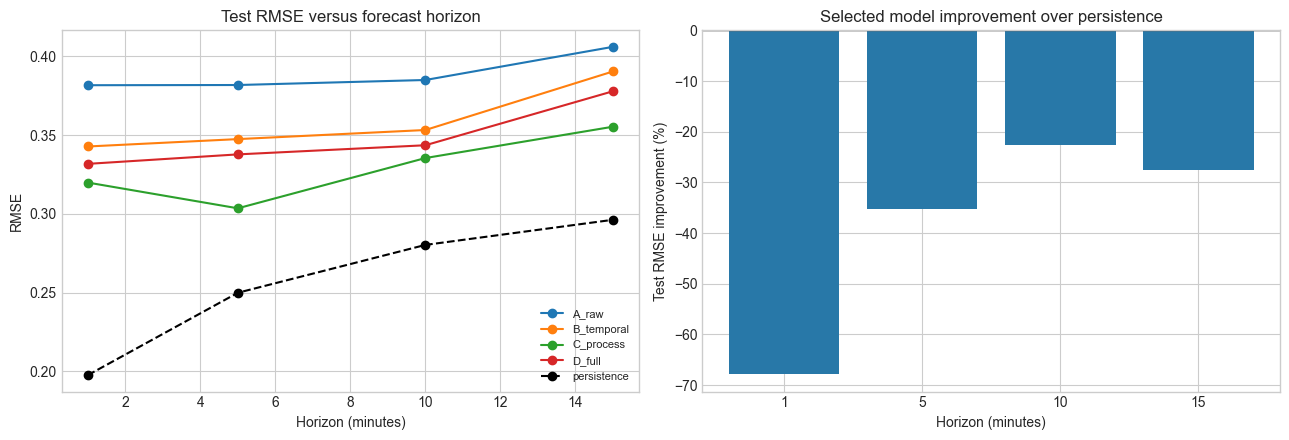

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for feature_set, group in best_model_per_configuration.groupby("feature_set"):
    axes[0].plot(group["horizon_min"], group["test_rmse"], marker="o", label=feature_set)
persistence_test = baseline_results.query("model == 'persistence' and split == 'test'")
axes[0].plot(persistence_test["horizon_min"], persistence_test["rmse"], marker="o", color="black", linestyle="--", label="persistence")
axes[0].set(title="Test RMSE versus forecast horizon", xlabel="Horizon (minutes)", ylabel="RMSE")
axes[0].legend(fontsize=8)
axes[1].bar(horizon_usefulness["horizon_min"].astype(str), horizon_usefulness["test_improvement_over_persistence_pct"], color="#2878a8")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Selected model improvement over persistence", xlabel="Horizon (minutes)", ylabel="Test RMSE improvement (%)")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "performance_vs_horizon_and_persistence.png", dpi=220); plt.show()


### 10.2 Feature-set ablation and complexity


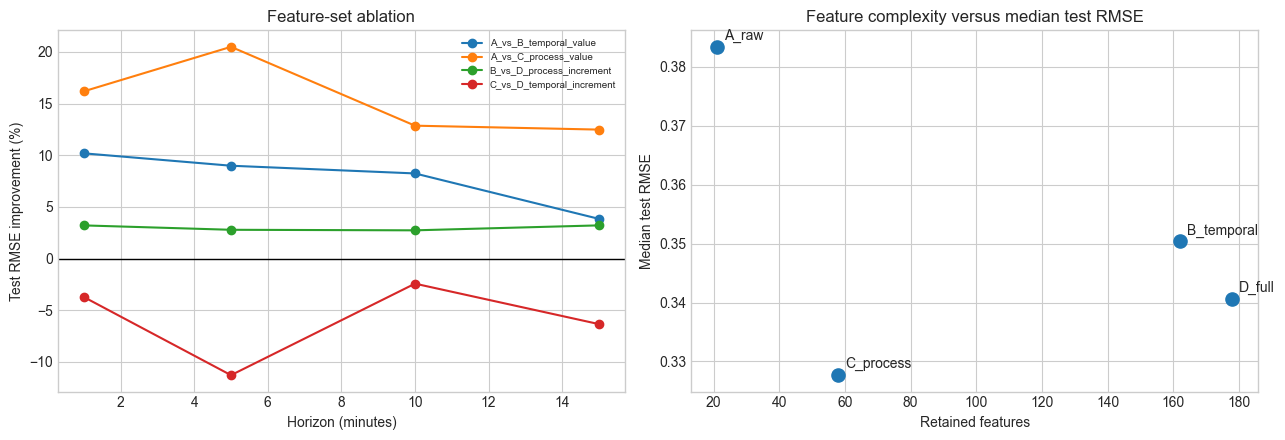

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for comparison, group in feature_set_ablation.groupby("comparison"):
    axes[0].plot(group["horizon_min"], group["test_rmse_improvement_pct"], marker="o", label=comparison)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="Feature-set ablation", xlabel="Horizon (minutes)", ylabel="Test RMSE improvement (%)")
axes[0].legend(fontsize=7)
complexity = best_model_per_configuration.groupby("feature_set").agg(features=("feature_count", "first"), median_test_rmse=("test_rmse", "median")).reset_index()
axes[1].scatter(complexity["features"], complexity["median_test_rmse"], s=90)
for _, row in complexity.iterrows(): axes[1].annotate(row["feature_set"], (row["features"], row["median_test_rmse"]), xytext=(5,5), textcoords="offset points")
axes[1].set(title="Feature complexity versus median test RMSE", xlabel="Retained features", ylabel="Median test RMSE")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "feature_set_ablation_and_complexity.png", dpi=220); plt.show()


### 10.3 Predicted versus actual and residual diagnostics


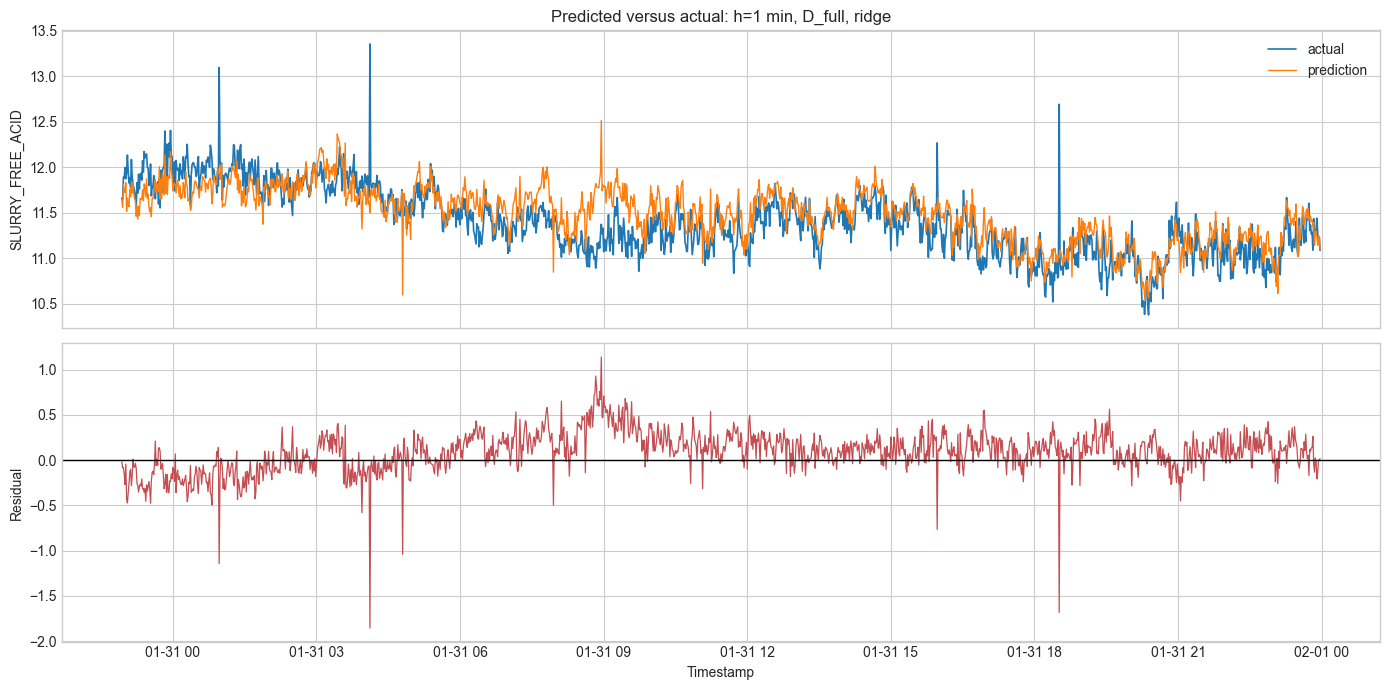

In [35]:
selected = best_accuracy_candidate
selected_test = residual_table.query("horizon_min == @selected.horizon_min and feature_set == @selected.feature_set and model == @selected.model and split == 'test'").tail(PREDICTION_PLOT_ROWS)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(selected_test["timestamp"], selected_test["y_true"], label="actual", linewidth=1.2)
axes[0].plot(selected_test["timestamp"], selected_test["y_pred"], label="prediction", linewidth=1.0)
axes[0].set(title=f"Predicted versus actual: h={int(selected.horizon_min)} min, {selected.feature_set}, {selected.model}", ylabel=TARGET)
axes[0].legend()
axes[1].plot(selected_test["timestamp"], selected_test["residual"], color="#c44e52", linewidth=.9)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(ylabel="Residual", xlabel="Timestamp")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "predicted_actual_and_residual_time_series.png", dpi=220); plt.show()


### 10.4 Representative transition window


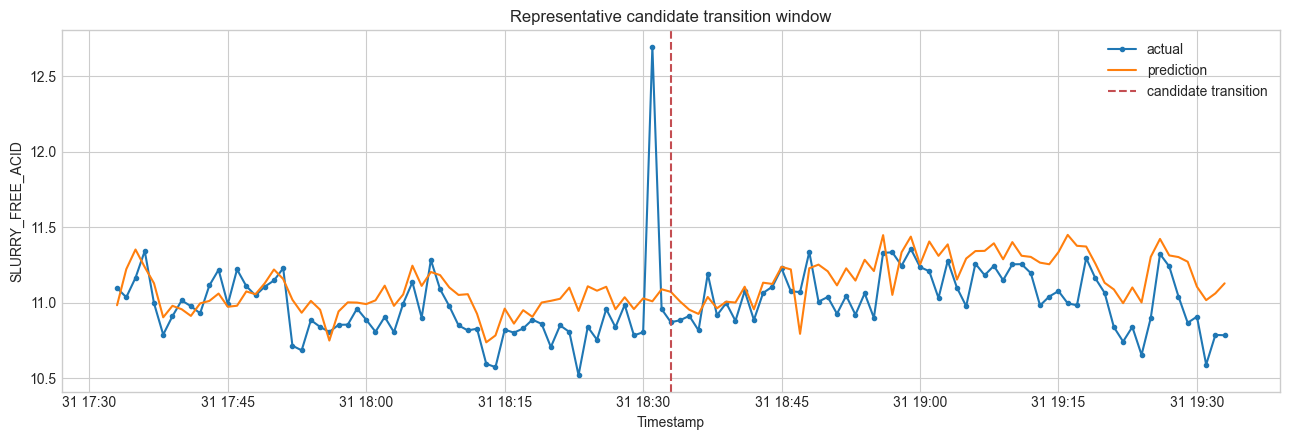

In [36]:
transition_rows = selected_test.query("candidate_regime == 'transition_candidate'")
transition_center = transition_rows.loc[transition_rows["current_absolute_change"].idxmax(), "timestamp"] if len(transition_rows) else selected_test.iloc[len(selected_test)//2]["timestamp"]
window = residual_table.query("horizon_min == @selected.horizon_min and feature_set == @selected.feature_set and model == @selected.model and split == 'test'").copy()
window = window[(window["timestamp"] >= transition_center - pd.Timedelta(minutes=60)) & (window["timestamp"] <= transition_center + pd.Timedelta(minutes=60))]
fig, ax = plt.subplots(figsize=(13, 4.5)); ax.plot(window["timestamp"], window["y_true"], label="actual", marker="."); ax.plot(window["timestamp"], window["y_pred"], label="prediction"); ax.axvline(transition_center, color="#c44e52", linestyle="--", label="candidate transition"); ax.set(title="Representative candidate transition window", xlabel="Timestamp", ylabel=TARGET); ax.legend(); fig.tight_layout(); fig.savefig(FIGURE_DIR / "representative_transition_window.png", dpi=220); plt.show()


### 10.5 Residual distribution and error by regime


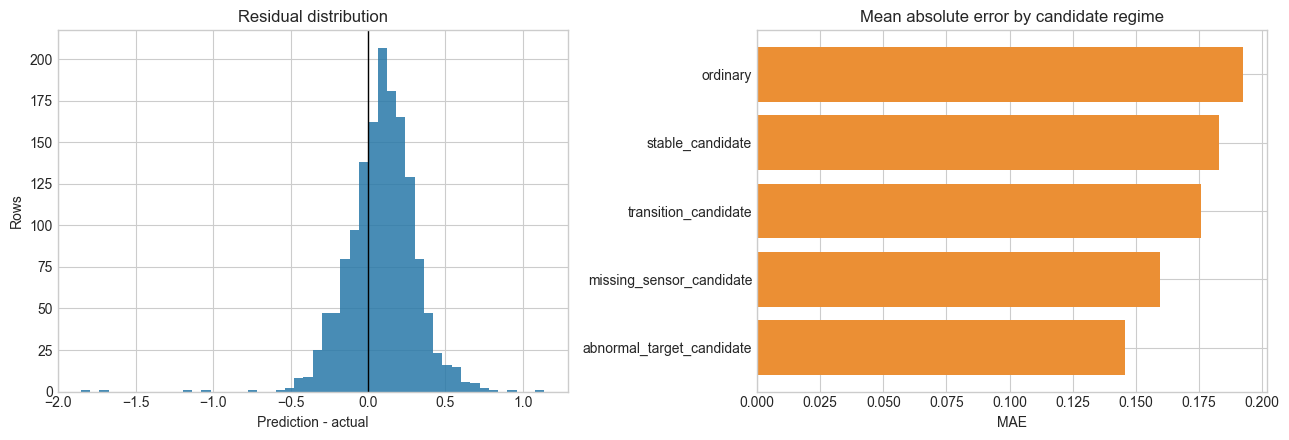

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(selected_test["residual"], bins=50, color="#2878a8", alpha=.85)
axes[0].axvline(0, color="black", linewidth=1); axes[0].set(title="Residual distribution", xlabel="Prediction - actual", ylabel="Rows")
regime_plot = selected_test.groupby("candidate_regime")["absolute_error"].mean().sort_values()
axes[1].barh(regime_plot.index, regime_plot.values, color="#eb8f34"); axes[1].set(title="Mean absolute error by candidate regime", xlabel="MAE")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "residual_distribution_and_regime_error.png", dpi=220); plt.show()


### 10.6 Grouped importance and stability


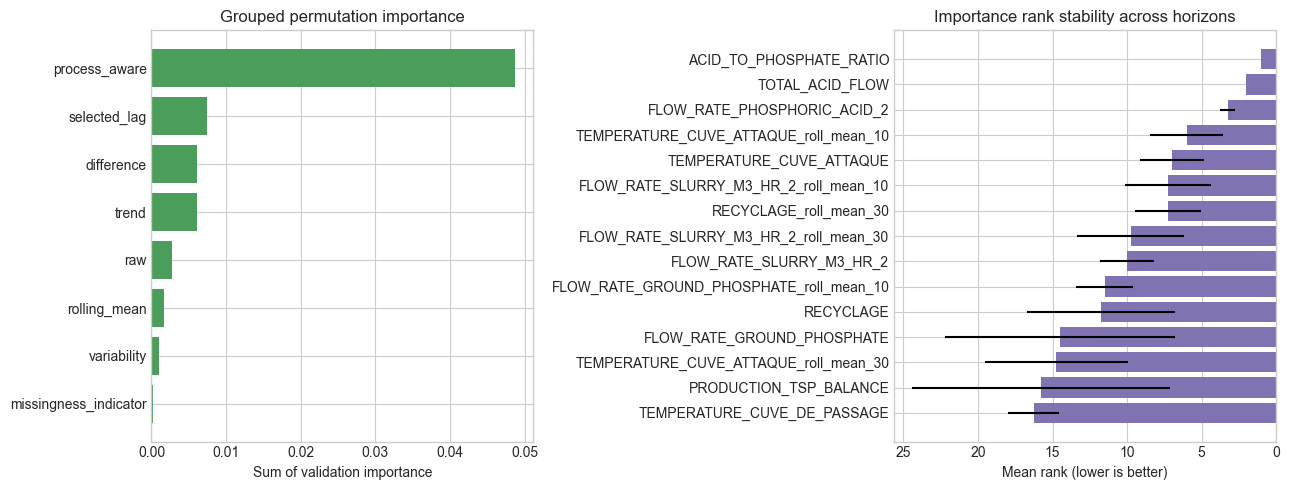

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
family_plot = grouped_family_importance.sort_values("permutation_importance_mean").tail(12)
axes[0].barh(family_plot["family"], family_plot["permutation_importance_mean"], color="#4a9d5b")
axes[0].set(title="Grouped permutation importance", xlabel="Sum of validation importance")
stability_plot = importance_stability_summary.query("horizons_present >= 2").head(15).sort_values("mean_rank", ascending=False)
axes[1].barh(stability_plot["feature"], stability_plot["mean_rank"], xerr=stability_plot["rank_std"].fillna(0), color="#8172b2")
axes[1].invert_xaxis(); axes[1].set(title="Importance rank stability across horizons", xlabel="Mean rank (lower is better)")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "grouped_importance_and_horizon_stability.png", dpi=220); plt.show()


### 10.7 Accuracy versus reaction-time trade-off


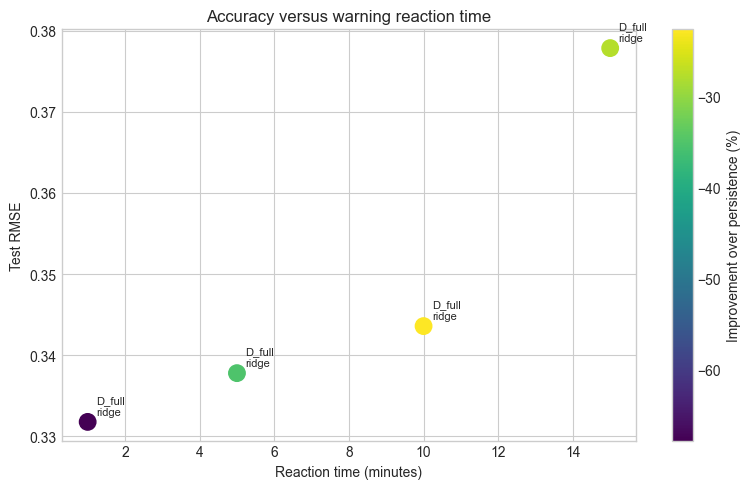

In [39]:
fig, ax = plt.subplots(figsize=(8, 5)); scatter = ax.scatter(horizon_usefulness["reaction_time_minutes"], horizon_usefulness["test_rmse"], c=horizon_usefulness["test_improvement_over_persistence_pct"], s=140, cmap="viridis")
for _, row in horizon_usefulness.iterrows(): ax.annotate(f"{row.selected_feature_set}\n{row.selected_model}", (row.reaction_time_minutes, row.test_rmse), xytext=(6,5), textcoords="offset points", fontsize=8)
ax.set(title="Accuracy versus warning reaction time", xlabel="Reaction time (minutes)", ylabel="Test RMSE"); fig.colorbar(scatter, ax=ax, label="Improvement over persistence (%)"); fig.tight_layout(); fig.savefig(FIGURE_DIR / "accuracy_reaction_time_tradeoff.png", dpi=220); plt.show()


## 11. Model-selection framework


### 11.1 Build a validation-led decision table


In [40]:
decision_rows = []
for role, candidate in [("accuracy_oriented", best_accuracy_candidate), ("interpretable", best_interpretable_candidate), ("early_warning", best_early_warning_candidate)]:
    h = int(candidate["horizon_min"])
    regime_subset = regime_metrics.query("horizon_min == @h and feature_set == @candidate.feature_set and model == @candidate.model and split == 'test'")
    transition_rmse = regime_subset.loc[regime_subset["candidate_regime"].eq("transition_candidate"), "rmse"]
    process_dependency = any(feature in process_feature_names for feature in modeling_datasets[(h, candidate["feature_set"])]["features"])
    decision_rows.append({
        "candidate_role": role, "horizon_min": h, "feature_set": candidate["feature_set"], "model": candidate["model"],
        "validation_rmse": candidate["validation_rmse"], "test_rmse": candidate["test_rmse"],
        "persistence_improvement_pct": candidate["test_improvement_over_persistence_pct"],
        "transition_candidate_rmse": transition_rmse.iloc[0] if len(transition_rmse) else np.nan,
        "feature_count": candidate["feature_count"], "training_seconds": candidate["training_seconds"],
        "interpretability": "high" if candidate["model"] == "ridge" else ("medium" if candidate["model"] == "extra_trees" else "medium-low"),
        "uses_process_aware_features": process_dependency,
        "operational_validation_burden": "higher" if process_dependency else "standard",
        "selection_basis": "validation performance plus role constraint; test not used for selection",
    })
model_selection_decision = pd.DataFrame(decision_rows)
display(model_selection_decision)


,candidate_role,horizon_min,feature_set,model,validation_rmse,test_rmse,persistence_improvement_pct,transition_candidate_rmse,feature_count,training_seconds,interpretability,uses_process_aware_features,operational_validation_burden,selection_basis
0,accuracy_oriented,1,D_full,ridge,0.334793,0.331762,-67.882934,0.332092,178,0.121259,high,True,higher,validation performance plus role constraint; t...
1,interpretable,1,D_full,ridge,0.334793,0.331762,-67.882934,0.332092,178,0.121259,high,True,higher,validation performance plus role constraint; t...
2,early_warning,10,D_full,ridge,0.339868,0.343577,-22.570643,0.338640,178,0.121892,high,True,higher,validation performance plus role constraint; t...


### 11.2 Refit and serialize final candidate models with preprocessors


In [41]:
final_candidate_bundle = {}
for _, row in model_selection_decision.iterrows():
    source_row = {"accuracy_oriented": best_accuracy_candidate, "interpretable": best_interpretable_candidate, "early_warning": best_early_warning_candidate}[row["candidate_role"]]
    model, key, preprocessing = refit_candidate(source_row)
    final_candidate_bundle[row["candidate_role"]] = {
        "model": model,
        "preprocessor": modeling_datasets[key]["pipelines"][preprocessing],
        "features": modeling_datasets[key]["features"],
        "horizon_min": key[0],
        "feature_set": key[1],
        "preprocessing_variant": preprocessing,
        "selected_hyperparameters": json.loads(source_row["selected_hyperparameters"]),
    }
joblib.dump(final_candidate_bundle, MODEL_DIR / "final_candidate_models_and_preprocessors.joblib")
print("Serialized final validation-selected candidate bundle.")


Serialized final validation-selected candidate bundle.


## 12. Export modeling artifacts


### 12.1 Export tables and configuration


In [42]:
experiment_configuration = pd.DataFrame([
    {"key": "horizons", "value": json.dumps(HORIZONS)},
    {"key": "feature_sets", "value": json.dumps(FEATURE_SETS)},
    {"key": "models", "value": json.dumps(ML_MODELS)},
    {"key": "tuning_candidates_per_model", "value": TUNING_BUDGET_PER_MODEL},
    {"key": "random_state", "value": RANDOM_STATE},
    {"key": "selection_metric", "value": "validation_rmse"},
    {"key": "test_use", "value": "evaluation only after validation selection"},
    {"key": "shuffling", "value": False},
])

table_exports = {
    "input_integrity_checks": input_integrity_checks,
    "complete_benchmark_results": complete_benchmark_results,
    "hyperparameter_search_results": tuning_results,
    "selected_hyperparameters": tuning_results.query("selected"),
    "test_predictions": model_predictions.query("split == 'test'"),
    "validation_predictions": model_predictions.query("split == 'valid'"),
    "residuals_with_candidate_regimes": residual_table,
    "candidate_regime_metrics": regime_metrics,
    "feature_set_ablation": feature_set_ablation,
    "horizon_usefulness": horizon_usefulness,
    "ridge_coefficient_importance": linear_importance,
    "extra_trees_importance": tree_importance,
    "permutation_importance": permutation_importance_table,
    "grouped_family_importance": grouped_family_importance,
    "grouped_source_importance": grouped_source_importance,
    "process_feature_contribution": process_feature_contribution,
    "importance_stability": importance_stability_summary,
    "largest_error_events": largest_error_events,
    "extreme_error_impact": extreme_error_impact,
    "model_selection_decision": model_selection_decision,
    "experiment_configuration": experiment_configuration,
}
for name, table in table_exports.items():
    table.to_csv(ARTIFACT_OUTPUT_DIR / f"{name}.csv", index=False)
print(f"Exported {len(table_exports)} modeling tables.")


Exported 21 modeling tables.


### 12.2 Verify the exact export manifest


In [43]:
EXPECTED_FIGURES = [
    "performance_vs_horizon_and_persistence.png",
    "feature_set_ablation_and_complexity.png",
    "predicted_actual_and_residual_time_series.png",
    "representative_transition_window.png",
    "residual_distribution_and_regime_error.png",
    "grouped_importance_and_horizon_stability.png",
    "accuracy_reaction_time_tradeoff.png",
]
expected_table_paths = [ARTIFACT_OUTPUT_DIR / f"{name}.csv" for name in table_exports]
expected_figure_paths = [FIGURE_DIR / name for name in EXPECTED_FIGURES]
expected_model_paths = [MODEL_DIR / "final_candidate_models_and_preprocessors.joblib"]
export_manifest = pd.DataFrame({"path": [str(path) for path in expected_table_paths + expected_figure_paths + expected_model_paths]})
export_manifest["exists"] = export_manifest["path"].map(lambda path: Path(path).exists())
assert export_manifest["exists"].all()
display(export_manifest)


,path,exists
0,..\reports\prediction_benchmark_artifacts\inpu...,True
1,..\reports\prediction_benchmark_artifacts\comp...,True
2,..\reports\prediction_benchmark_artifacts\hype...,True
3,..\reports\prediction_benchmark_artifacts\sele...,True
4,..\reports\prediction_benchmark_artifacts\test...,True
5,..\reports\prediction_benchmark_artifacts\vali...,True
6,..\reports\prediction_benchmark_artifacts\resi...,True
7,..\reports\prediction_benchmark_artifacts\cand...,True
8,..\reports\prediction_benchmark_artifacts\feat...,True
9,..\reports\prediction_benchmark_artifacts\hori...,True


## 13. Final readiness checks


### 13.1 Execute release assertions


In [44]:
evaluated_ml_keys = set(map(tuple, benchmark_results[["horizon_min", "feature_set"]].drop_duplicates().to_numpy()))
persistence_horizons = set(baseline_results.query("model == 'persistence'")["horizon_min"])
prediction_alignment = all(
    len(group) == len(modeling_datasets[(h, feature_set)][f"y_{split}"])
    for (h, feature_set, model, split), group in model_predictions.groupby(["horizon_min", "feature_set", "model", "split"])
)

readiness_checks = pd.DataFrame([
    {"check": "all_16_experiment_configurations_evaluated", "status": evaluated_ml_keys == expected_keys},
    {"check": "persistence_evaluated_at_every_horizon", "status": persistence_horizons == set(HORIZONS)},
    {"check": "preprocessing_recovered_from_train_fitted_notebook_02_objects", "status": input_integrity_checks["four_fitted_preprocessors"].all()},
    {"check": "test_not_used_for_hyperparameter_selection", "status": tuning_results["selected"].groupby([tuning_results.horizon_min, tuning_results.feature_set, tuning_results.model]).sum().eq(1).all()},
    {"check": "target_and_future_target_leakage_absent", "status": input_integrity_checks[["target_absent", "future_targets_absent"]].all().all()},
    {"check": "prediction_rows_align_with_split_targets", "status": prediction_alignment},
    {"check": "benchmark_result_keys_are_unique", "status": not complete_benchmark_results.duplicated(["horizon_min", "feature_set", "model"]).any()},
    {"check": "all_expected_artifacts_exist", "status": export_manifest["exists"].all()},
    {"check": "no_unconfirmed_variable_used_for_intervention_recommendation", "status": not variable_registry["recommendation_allowed"].any()},
    {"check": "same_hyperparameter_budget_for_each_ml_family", "status": all(len(spec["candidates"]) == TUNING_BUDGET_PER_MODEL for spec in MODEL_SPECS.values())},
])
readiness_checks.to_csv(ARTIFACT_OUTPUT_DIR / "readiness_checks.csv", index=False)
assert readiness_checks["status"].all(), readiness_checks.loc[~readiness_checks["status"]]
display(readiness_checks)


,check,status
0,all_16_experiment_configurations_evaluated,True
1,persistence_evaluated_at_every_horizon,True
2,preprocessing_recovered_from_train_fitted_note...,True
3,test_not_used_for_hyperparameter_selection,True
4,target_and_future_target_leakage_absent,True
5,prediction_rows_align_with_split_targets,True
6,benchmark_result_keys_are_unique,True
7,all_expected_artifacts_exist,True
8,no_unconfirmed_variable_used_for_intervention_...,True
9,same_hyperparameter_budget_for_each_ml_family,True


### 13.2 Observations: release status


In [45]:
print(f"Passed {readiness_checks.status.sum()}/{len(readiness_checks)} modeling readiness checks.")
print(f"Artifacts: {len(table_exports) + 1} CSV tables, {len(EXPECTED_FIGURES)} figures, and {len(expected_model_paths)} serialized model bundle.")


Passed 10/10 modeling readiness checks.
Artifacts: 22 CSV tables, 7 figures, and 1 serialized model bundle.


## 14. Evidence-based conclusions


### 14.1 Generate direct answers from executed results


In [46]:
positive_horizons = horizon_usefulness.loc[horizon_usefulness["test_improvement_over_persistence_pct"] > 0, "horizon_min"].astype(int).tolist()
best_feature_set_overall = best_model_per_configuration.groupby("feature_set")["validation_rmse"].mean().idxmin()
process_ablation = feature_set_ablation.query("comparison in ['A_vs_C_process_value', 'B_vs_D_process_increment']")
process_value_supported = process_ablation["validation_consistent_improvement"].mean() > 0.5
best_warning = horizon_usefulness.sort_values(["test_improvement_over_persistence_pct", "reaction_time_minutes"], ascending=[False, False]).iloc[0]
worst_regime = error_failure_summary.index[0]

conclusion_table = pd.DataFrame([
    {"question": "Does forecasting beat persistence?", "answer": "Yes on test RMSE at horizons " + str(positive_horizons) if positive_horizons else "No selected horizon improves on persistence."},
    {"question": "Which feature set is strongest on validation on average?", "answer": best_feature_set_overall},
    {"question": "Do process-aware features add consistent value?", "answer": "Supported across most requested validation ablations." if process_value_supported else "Not consistently supported across the requested validation ablations."},
    {"question": "Best interpretable candidate", "answer": f"Ridge, h={int(best_interpretable_candidate.horizon_min)} min, {best_interpretable_candidate.feature_set}"},
    {"question": "Most promising warning trade-off in this benchmark", "answer": f"h={int(best_warning.horizon_min)} min, {best_warning.selected_feature_set}, {best_warning.selected_model}; operational thresholds remain unvalidated."},
    {"question": "Where are errors most difficult?", "answer": str(worst_regime)},
    {"question": "Operational readiness", "answer": "Research benchmark complete; additional months, event labels, units, thresholds, and process-engineer validation are required before operational prototyping."},
])
display(conclusion_table)


,question,answer
0,Does forecasting beat persistence?,No selected horizon improves on persistence.
1,Which feature set is strongest on validation o...,D_full
2,Do process-aware features add consistent value?,Supported across most requested validation abl...
3,Best interpretable candidate,"Ridge, h=1 min, D_full"
4,Most promising warning trade-off in this bench...,"h=10 min, D_full, ridge; operational threshold..."
5,Where are errors most difficult?,startup_shutdown_candidate
6,Operational readiness,Research benchmark complete; additional months...


### 14.2 Limitations and required process information

- The dataset covers only January 2026; seasonal, campaign, and product-grade generalization is unknown.
- Candidate startup, shutdown, transition, and abnormal regimes are algorithmic labels, not confirmed event records.
- Warning thresholds are derived from training quantiles for analysis only and are not operational limits.
- The units of phosphoric-acid flow, ground-phosphate flow, fuel-oil flow, steam flow, wash-liquid flow, and recycle remain unresolved.
- The exact material represented by `RECYCLAGE` remains unresolved.
- The two slurry volumetric tags are confirmed additive m³/h measurements, but `SLURRY_DENSITY_PROXY` remains provisional until the t/h measurement is confirmed to represent the same combined stream.
- Adjacent one-minute observations are dependent; rolling-origin evaluation across additional months is required.
- Model importance is predictive association, never proof of physical causation or a safe intervention.

## 15. Recommended continuation

Before operational prototyping, obtain additional months of data, confirmed process-event labels, engineering units, quality thresholds, and explicit actuator controllability. Then repeat this benchmark with rolling-origin validation and compare stability across campaigns or product grades.
